# Clinical Relevance Analysis — GradNorm branch

Formal verification (Marabou) proved that the trained network satisfies `safeFar` and `safeNear`:
no input in the verified domain produces a dose that would push concentration above C_safe.

However, a model can pass verification by being pathologically conservative — predicting near-zero
doses regardless of the patient's state. That is formally safe but clinically useless.

This notebook asks the separate question: **are the dose predictions therapeutically meaningful?**

- Does the model prescribe meaningfully higher doses when a patient is sicker (high T, high WBC)?
- Does it suppress doses appropriately when concentration is already high?
- Or has constraint training flattened predictions toward a single conservative value?
- Where the model is wrong, is it wrong in a dangerous direction (overdose) or a merely suboptimal one (underdose)?

**Branch:** `trial/pdt-training` — GradNorm adaptive loss balancing  
**Model evaluated:** `models/pk_model.keras` (5 features: C, T, WBC, Age, Weight)  
**Key difference from manual branch:** doses are normalised during training (y_scaler);
predictions must be inverse-transformed for clinical evaluation.

### Sections
1. Setup
2. Predictions vs targets
3. Error distribution
4. Residuals by feature
5. Effective Ke analysis
6. Worst-case predictions
7. Safety margin behaviour
8. Interpretation


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from drug_verification.simulation import simulate_cohort, generate_patient_covariates, compute_effective_params
from drug_verification.training import prepare_data
from drug_verification.types import SimulationConfig
from drug_verification import constants as C

MODEL_PATH = "models/pk_model.keras"
NUM_PATIENTS = 50
TIMESTEPS    = 48
SEED         = 42
ROWS_PER_PATIENT = TIMESTEPS - 1

tf.random.set_seed(SEED)
np.random.seed(SEED)

model = tf.keras.models.load_model(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")
model.summary()

I0000 00:00:1775143976.420969   47356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775143976.421638   47356 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775143976.462761   47356 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775143977.948108   47356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Loaded: models/pk_model.keras


E0000 00:00:1775143978.689945   47356 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/melon501/source/drug-verification/venv_clinical/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,269 (106.52 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,180 (71.02 KB)

In [2]:
cfg = SimulationConfig(num_patients=NUM_PATIENTS, timesteps=TIMESTEPS, seed=SEED)
X, y = simulate_cohort(cfg, seed=SEED)

# This branch normalises y during training — prepare_data returns y_scaler too
X_train, X_test, y_train, y_test, scaler, y_scaler = prepare_data(X, y, seed=SEED)

# Predict in normalised space, then inverse-transform to mg
X_scaled = scaler.transform(X)
y_pred_norm = model.predict(X_scaled, verbose=0).flatten()
y_pred = y_scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
residuals = y_pred - y

patient_ids  = np.repeat(np.arange(NUM_PATIENTS), ROWS_PER_PATIENT)
timestep_ids = np.tile(np.arange(ROWS_PER_PATIENT), NUM_PATIENTS)

print(f"Samples: {X.shape[0]}  ({NUM_PATIENTS} patients x {ROWS_PER_PATIENT} timesteps)")
print(f"MAE:              {np.mean(np.abs(residuals)):.2f} mg")
print(f"Median |error|:   {np.median(np.abs(residuals)):.2f} mg")
print(f"95th pct |error|: {np.percentile(np.abs(residuals), 95):.2f} mg")
print(f"Max absolute err: {np.max(np.abs(residuals)):.2f} mg")
print(f"Bias (mean err):  {np.mean(residuals):+.2f} mg  ({'over' if np.mean(residuals) > 0 else 'under'}dosing on average)")
print(f"Within 50 mg:     {100*np.mean(np.abs(residuals)<50):.1f}%")
print(f"Within 100 mg:    {100*np.mean(np.abs(residuals)<100):.1f}%")

Samples: 2350  (50 patients x 47 timesteps)
MAE:              8.25 mg
Median |error|:   4.18 mg
95th pct |error|: 27.95 mg
Max absolute err: 173.23 mg
Bias (mean err):  +0.97 mg  (overdosing on average)
Within 50 mg:     97.9%
Within 100 mg:    99.5%


## 2. Predictions vs targets

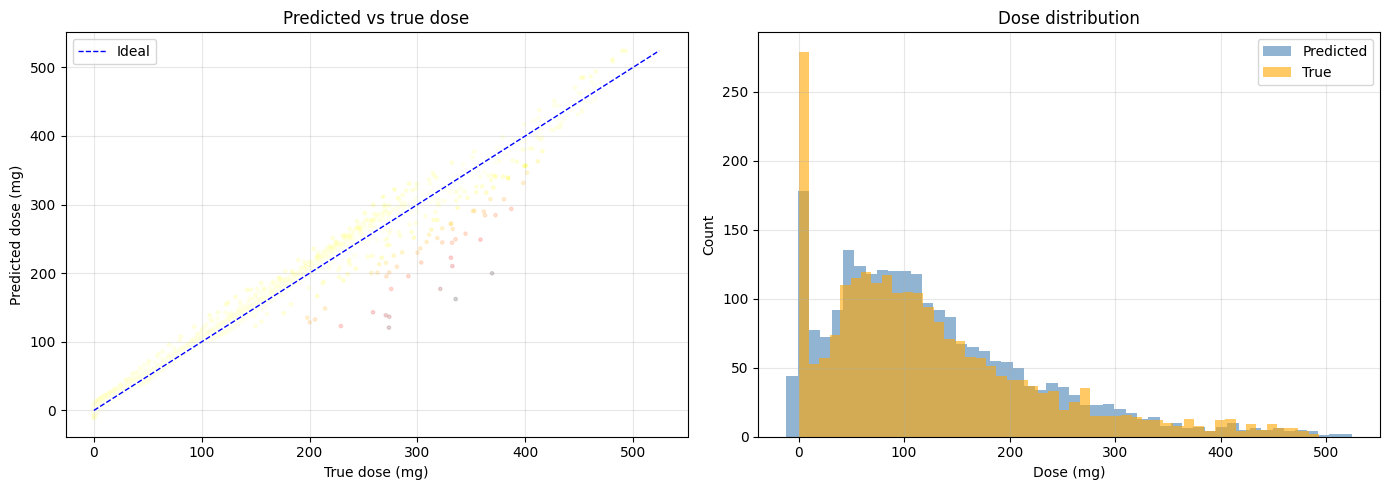

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y, y_pred, alpha=0.15, s=6, c=np.abs(residuals), cmap='hot_r')
lim = [0, max(y.max(), y_pred.max())]
ax.plot(lim, lim, 'b--', linewidth=1, label='Ideal')
ax.set_xlabel('True dose (mg)')
ax.set_ylabel('Predicted dose (mg)')
ax.set_title('Predicted vs true dose')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(y_pred, bins=50, alpha=0.6, label='Predicted', color='steelblue')
ax.hist(y, bins=50, alpha=0.6, label='True', color='orange')
ax.set_xlabel('Dose (mg)')
ax.set_ylabel('Count')
ax.set_title('Dose distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Error distribution

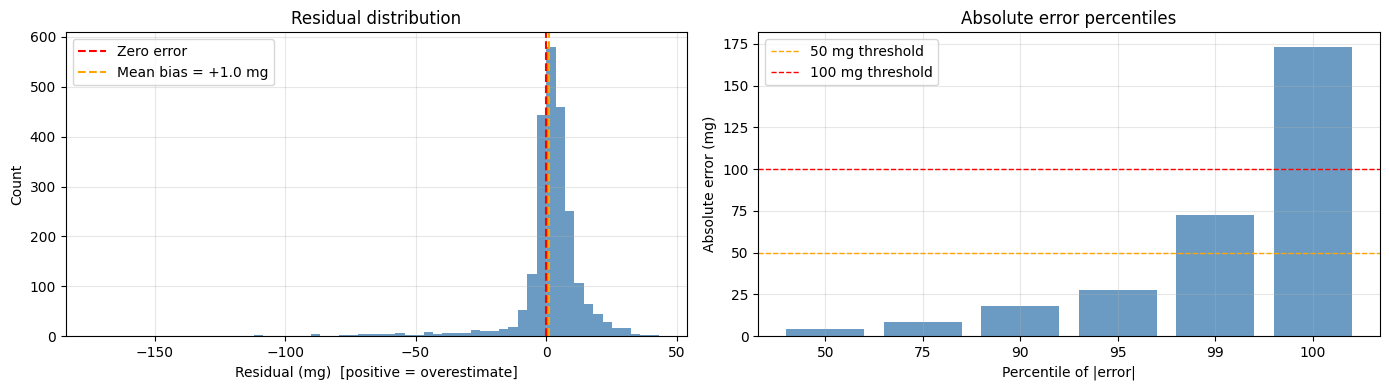

Absolute error percentiles:
   50th: 4.2 mg
   75th: 8.7 mg
   90th: 18.0 mg
   95th: 27.9 mg
   99th: 72.6 mg
  100th: 173.2 mg


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(residuals, bins=60, color='steelblue', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(np.mean(residuals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean bias = {np.mean(residuals):+.1f} mg')
ax.set_xlabel('Residual (mg)  [positive = overestimate]')
ax.set_ylabel('Count')
ax.set_title('Residual distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
percentiles = [50, 75, 90, 95, 99, 100]
abs_errs = [np.percentile(np.abs(residuals), p) for p in percentiles]
ax.bar([str(p) for p in percentiles], abs_errs, color='steelblue', alpha=0.8)
ax.axhline(50, color='orange', linestyle='--', linewidth=1, label='50 mg threshold')
ax.axhline(100, color='red', linestyle='--', linewidth=1, label='100 mg threshold')
ax.set_xlabel('Percentile of |error|')
ax.set_ylabel('Absolute error (mg)')
ax.set_title('Absolute error percentiles')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Absolute error percentiles:")
for p, e in zip(percentiles, abs_errs):
    print(f"  {p:3d}th: {e:.1f} mg")

## 4. Residuals by feature

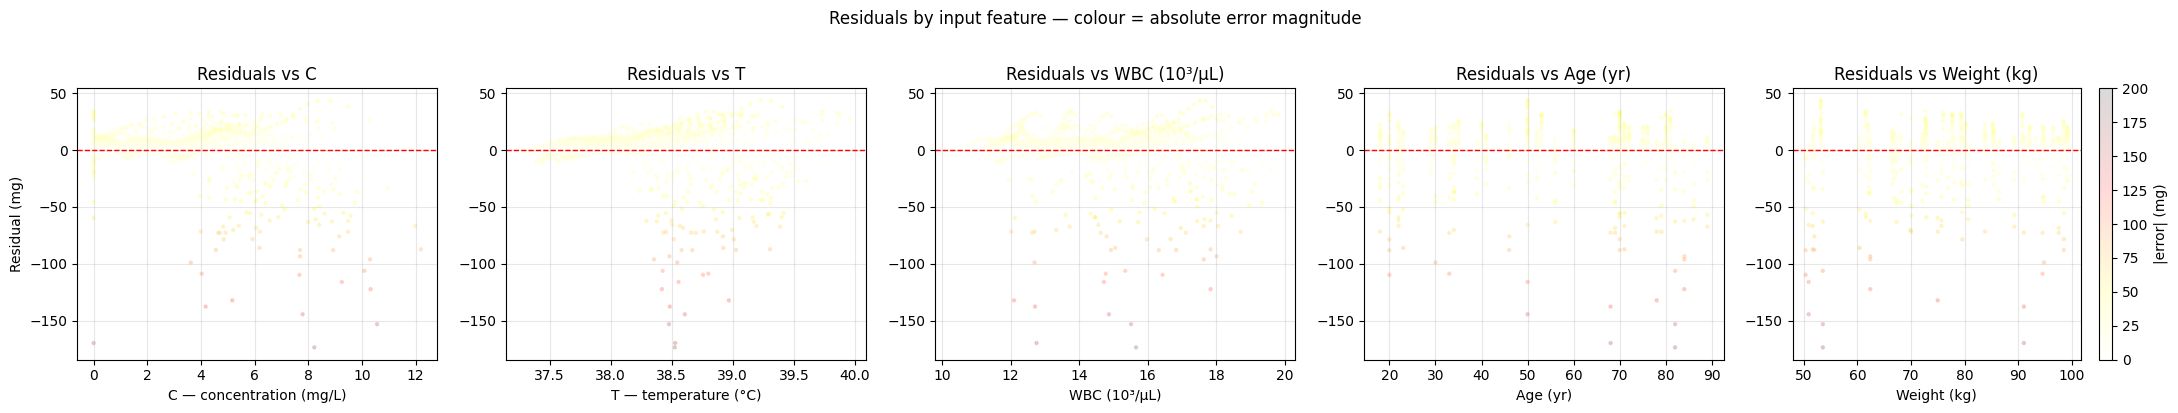

In [5]:
feature_names = ['C — concentration (mg/L)', 'T — temperature (°C)', 'WBC (10³/µL)', 'Age (yr)', 'Weight (kg)']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    sc = ax.scatter(X[:, i], residuals, alpha=0.15, s=5,
                    c=np.abs(residuals), cmap='hot_r', vmin=0, vmax=200)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(name)
    ax.set_ylabel('Residual (mg)' if i == 0 else '')
    ax.set_title(f'Residuals vs {name.split("—")[0].strip()}')
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes[-1], label='|error| (mg)')
plt.suptitle('Residuals by input feature — colour = absolute error magnitude', y=1.02)
plt.tight_layout()
plt.show()

## 5. Effective Ke analysis

Each patient's elimination rate is adjusted by age:

    ke_eff = Ke_baseline × (1 − 0.004 × (age − 50))

Fast-elimination patients (young, high ke_eff) reach lower trough concentrations.
This section checks whether the GradNorm model is less accurate for those patients
compared to the manual phase_switch model.


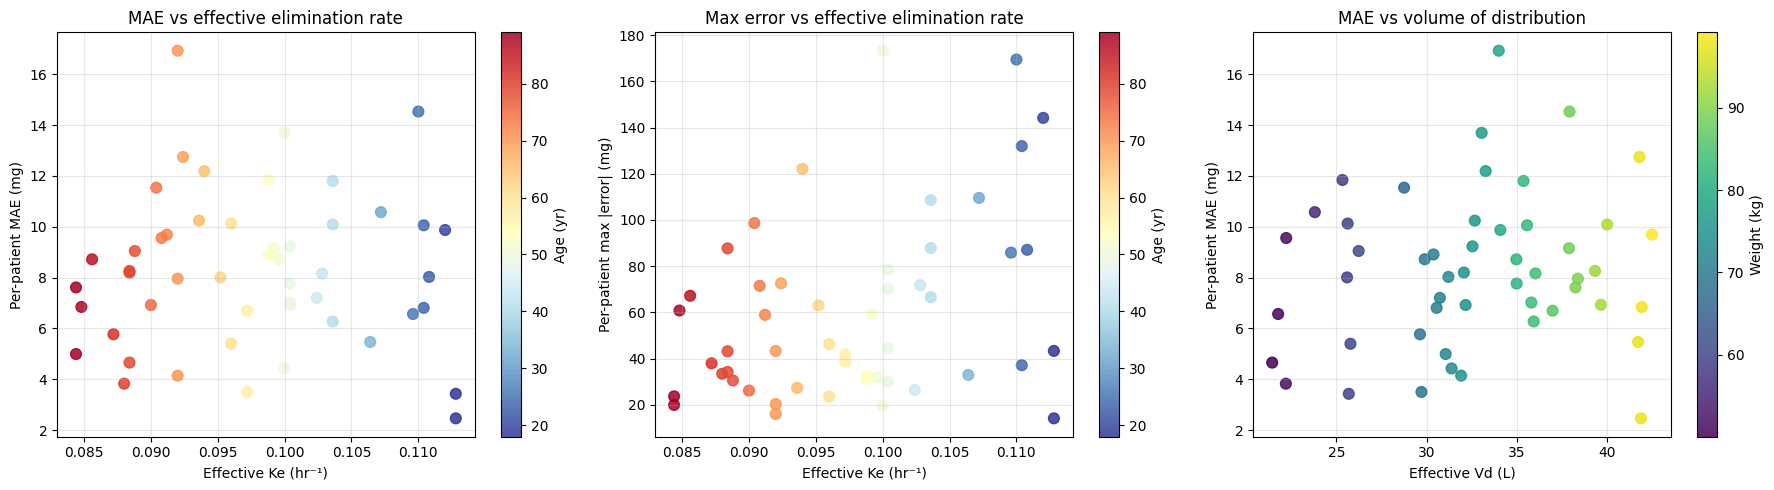

Correlation: ke_eff vs per-patient MAE:  r=+0.002
Correlation: ke_eff vs per-patient max:  r=+0.359
Correlation: age    vs per-patient MAE:  r=-0.002


In [6]:
rng = np.random.RandomState(SEED)
patient_ages, patient_weights, patient_ke_eff, patient_vd_eff = [], [], [], []
for _ in range(NUM_PATIENTS):
    pat = generate_patient_covariates(rng)
    eff = compute_effective_params(pat, cfg, rng)
    patient_ages.append(pat.age)
    patient_weights.append(pat.weight)
    patient_ke_eff.append(eff.ke_eff)
    patient_vd_eff.append(eff.Vd_eff)

patient_ages   = np.array(patient_ages)
patient_ke_eff = np.array(patient_ke_eff)
patient_vd_eff = np.array(patient_vd_eff)

per_patient_mae  = np.array([np.mean(np.abs(residuals[patient_ids==i])) for i in range(NUM_PATIENTS)])
per_patient_max  = np.array([np.max(np.abs(residuals[patient_ids==i]))  for i in range(NUM_PATIENTS)])
per_patient_bias = np.array([np.mean(residuals[patient_ids==i])         for i in range(NUM_PATIENTS)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
sc = ax.scatter(patient_ke_eff, per_patient_mae, c=patient_ages, cmap='RdYlBu_r', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Age (yr)')
ax.set_xlabel('Effective Ke (hr⁻¹)')
ax.set_ylabel('Per-patient MAE (mg)')
ax.set_title('MAE vs effective elimination rate')
ax.grid(True, alpha=0.3)

ax = axes[1]
sc = ax.scatter(patient_ke_eff, per_patient_max, c=patient_ages, cmap='RdYlBu_r', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Age (yr)')
ax.set_xlabel('Effective Ke (hr⁻¹)')
ax.set_ylabel('Per-patient max |error| (mg)')
ax.set_title('Max error vs effective elimination rate')
ax.grid(True, alpha=0.3)

ax = axes[2]
sc = ax.scatter(patient_vd_eff, per_patient_mae, c=patient_weights, cmap='viridis', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Weight (kg)')
ax.set_xlabel('Effective Vd (L)')
ax.set_ylabel('Per-patient MAE (mg)')
ax.set_title('MAE vs volume of distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation: ke_eff vs per-patient MAE:  r={np.corrcoef(patient_ke_eff, per_patient_mae)[0,1]:+.3f}")
print(f"Correlation: ke_eff vs per-patient max:  r={np.corrcoef(patient_ke_eff, per_patient_max)[0,1]:+.3f}")
print(f"Correlation: age    vs per-patient MAE:  r={np.corrcoef(patient_ages, per_patient_mae)[0,1]:+.3f}")

## 6. Worst-case predictions

In [7]:
N_WORST = 10
worst_idx = np.argsort(np.abs(residuals))[-N_WORST:][::-1]

print(f"{'Rank':<5} {'|Error|':>8} {'Residual':>10} {'True':>8} {'Pred':>8} "
      f"{'Conc':>6} {'Temp':>6} {'WBC':>5} {'Age':>4} {'Wt':>4} {'ts':>4}")
print("-" * 85)
for rank, idx in enumerate(worst_idx):
    pid = patient_ids[idx]
    print(f"{rank+1:<5} {abs(residuals[idx]):>8.1f} {residuals[idx]:>+10.1f} "
          f"{y[idx]:>8.1f} {y_pred[idx]:>8.1f} "
          f"{X[idx,0]:>6.2f} {X[idx,1]:>6.2f} {X[idx,2]:>5.1f} "
          f"{X[idx,3]:>4.0f} {X[idx,4]:>4.0f} {timestep_ids[idx]:>4}")

Rank   |Error|   Residual     True     Pred   Conc   Temp   WBC  Age   Wt   ts
-------------------------------------------------------------------------------------
1        173.2     -173.2    335.5    162.2   8.22  38.52  15.7   82   54    1
2        169.4     -169.4    369.2    199.8   0.00  38.53  12.8   68   91    0
3        152.9     -152.9    273.6    120.7  10.56  38.48  15.5   82   54    2
4        144.2     -144.2    321.2    177.1   7.79  38.61  14.9   50   51    1
5        137.4     -137.4    273.9    136.5   4.17  38.48  12.7   68   91    1
6        132.0     -132.0    270.6    138.7   5.17  38.97  12.1   78   75    1
7        122.1     -122.1    332.4    210.3  10.32  38.42  17.8   84   62    2
8        115.8     -115.8    258.8    143.1   9.25  38.56  14.7   50   51    2
9        109.6     -109.6    358.5    248.9   7.67  38.76  16.4   20   50    1
10       108.6     -108.6    331.1    222.5   4.03  38.80  14.8   33   95    1


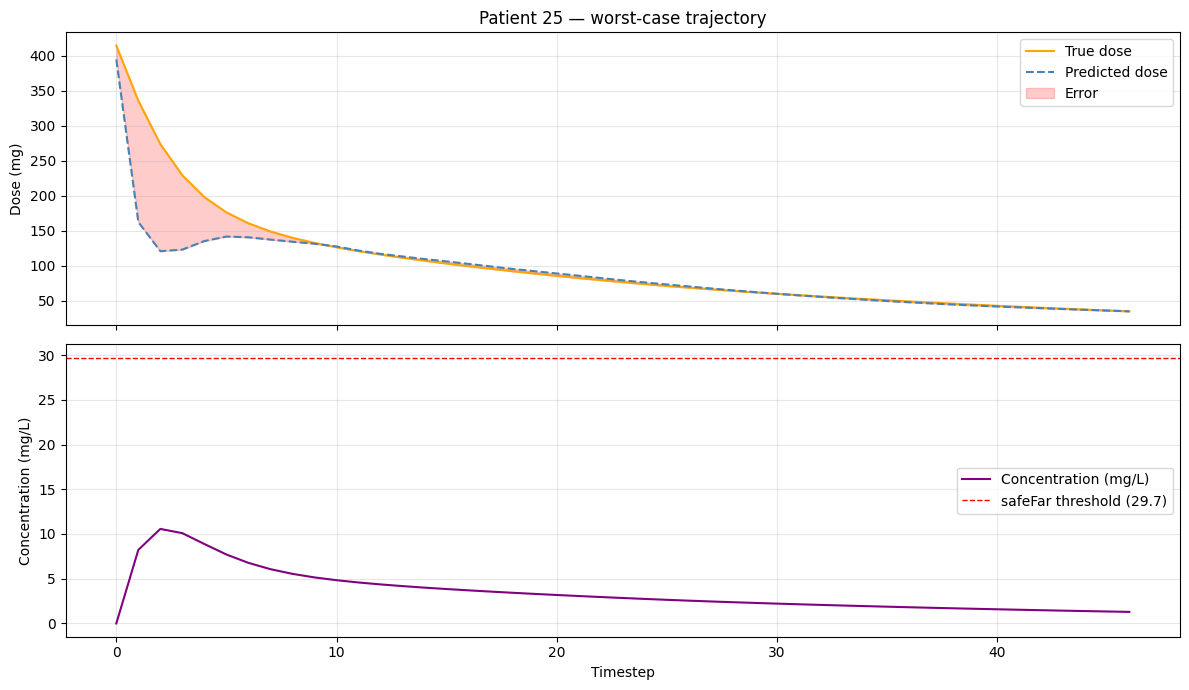

In [8]:
worst_patient = patient_ids[worst_idx[0]]
mask = patient_ids == worst_patient
ts   = timestep_ids[mask]
sort = np.argsort(ts)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(ts[sort], y[mask][sort], label='True dose', color='orange')
ax.plot(ts[sort], y_pred[mask][sort], label='Predicted dose', color='steelblue', linestyle='--')
ax.fill_between(ts[sort], y[mask][sort], y_pred[mask][sort], alpha=0.2, color='red', label='Error')
ax.set_ylabel('Dose (mg)')
ax.set_title(f'Patient {worst_patient} — worst-case trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ts[sort], X[mask][sort, 0], color='purple', label='Concentration (mg/L)')
ax.axhline(C.C_MAX * 0.99, color='red', linestyle='--', linewidth=1, label='safeFar threshold (29.7)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Concentration (mg/L)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Safety margin behaviour

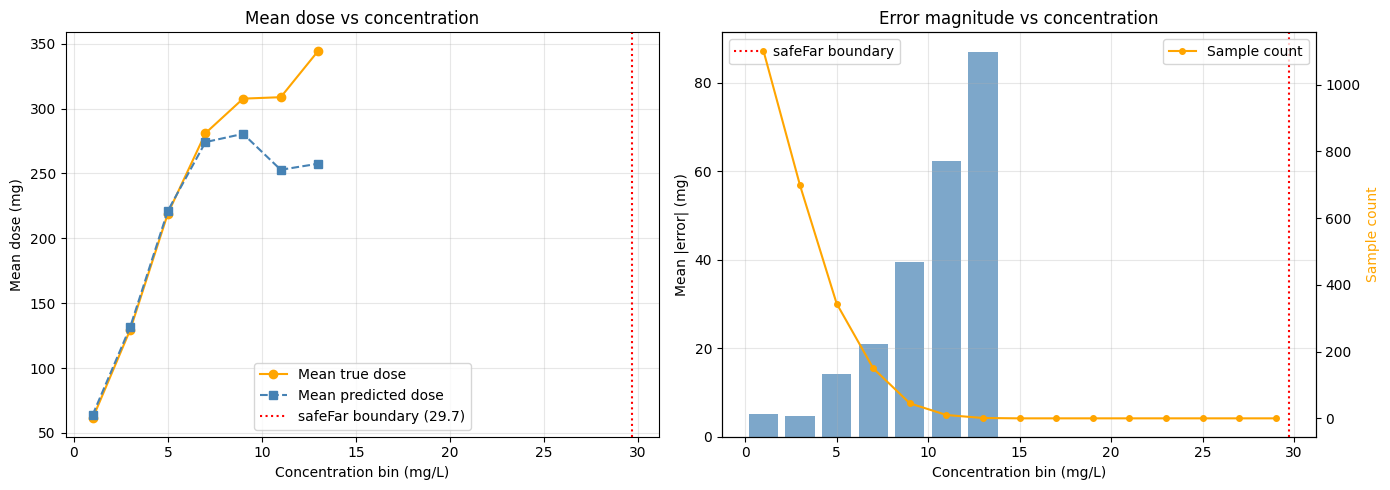

In [9]:
conc = X[:, 0]
bins = np.linspace(0, C.C_MAX, 16)
bin_idx = np.digitize(conc, bins) - 1

bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_pred  = [np.mean(y_pred[bin_idx==i]) if np.any(bin_idx==i) else np.nan for i in range(len(bins)-1)]
bin_true  = [np.mean(y[bin_idx==i])      if np.any(bin_idx==i) else np.nan for i in range(len(bins)-1)]
bin_mae   = [np.mean(np.abs(residuals[bin_idx==i])) if np.any(bin_idx==i) else np.nan for i in range(len(bins)-1)]
bin_count = [np.sum(bin_idx==i) for i in range(len(bins)-1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(bin_centers, bin_true, 'o-', color='orange', label='Mean true dose')
ax.plot(bin_centers, bin_pred, 's--', color='steelblue', label='Mean predicted dose')
ax.axvline(C.C_MAX * 0.99, color='red', linestyle=':', linewidth=1.5, label='safeFar boundary (29.7)')
ax.set_xlabel('Concentration bin (mg/L)')
ax.set_ylabel('Mean dose (mg)')
ax.set_title('Mean dose vs concentration')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(bin_centers, bin_mae, width=(bins[1]-bins[0])*0.8, color='steelblue', alpha=0.7)
ax.axvline(C.C_MAX * 0.99, color='red', linestyle=':', linewidth=1.5, label='safeFar boundary')
ax2 = ax.twinx()
ax2.plot(bin_centers, bin_count, 'o-', color='orange', markersize=4, label='Sample count')
ax2.set_ylabel('Sample count', color='orange')
ax.set_xlabel('Concentration bin (mg/L)')
ax.set_ylabel('Mean |error| (mg)')
ax.set_title('Error magnitude vs concentration')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Interpretation

In [ ]:
mae       = np.mean(np.abs(residuals))
max_err   = np.max(np.abs(residuals))
p95       = np.percentile(np.abs(residuals), 95)
p99       = np.percentile(np.abs(residuals), 99)
bias      = np.mean(residuals)
pct_50    = 100 * np.mean(np.abs(residuals) < 50)
pct_100   = 100 * np.mean(np.abs(residuals) < 100)
pred_std  = np.std(y_pred)
true_std  = np.std(y)
corr      = np.corrcoef(y, y_pred)[0, 1]

# Dose response check
temp_q1 = np.percentile(X[:,1], 25)
temp_q3 = np.percentile(X[:,1], 75)
dose_low_temp  = y_pred[X[:,1] <= temp_q1].mean()
dose_high_temp = y_pred[X[:,1] >= temp_q3].mean()

print("=" * 55)
print("  Clinical Relevance Summary — GradNorm branch")
print("=" * 55)
print(f"  MAE                   {mae:>8.1f} mg")
print(f"  95th percentile error {p95:>8.1f} mg")
print(f"  99th percentile error {p99:>8.1f} mg")
print(f"  Max absolute error    {max_err:>8.1f} mg")
print(f"  Mean bias             {bias:>+8.1f} mg")
print(f"  Within 50 mg          {pct_50:>7.1f}%")
print(f"  Within 100 mg         {pct_100:>7.1f}%")
print()
print(f"  Pred std / True std   {pred_std/true_std:>8.3f}  (1.0 = perfectly responsive)")
print(f"  Corr(true, pred)      {corr:>8.3f}")
print()
print(f"  Low temp dose:  {dose_low_temp:.1f} mg")
print(f"  High temp dose: {dose_high_temp:.1f} mg  (ratio: {dose_high_temp/dose_low_temp:.2f}x)")
print()
print("  Formal safety: (see verification results)")
print()
if corr > 0.95:
    print("Model is clinically responsive (r > 0.95).")
elif corr > 0.85:
    print("Model shows moderate clinical responsiveness (r > 0.85).")
else:
    print("Warning: low correlation — model may not be clinically responsive.")
if pred_std / true_std < 0.5:
    print("Warning: prediction std is less than half of true std — model may be over-conservative.")
else:
    print("Prediction variance is comparable to true dose variance — not a flat predictor.")

  Clinical Relevance Summary — GradNorm branch
  MAE                        8.3 mg
  95th percentile error     27.9 mg
  99th percentile error     72.6 mg
  Max absolute error       173.2 mg
  Mean bias                 +1.0 mg
  Within 50 mg             97.9%
  Within 100 mg            99.5%

  Pred std / True std      0.972  (1.0 = perfectly responsive)
  Corr(true, pred)         0.988

  Low temp dose:  60.9 mg
  High temp dose: 249.9 mg  (ratio: 4.10x)

  Formal safety: (see verification results)

Model is clinically responsive (r > 0.95).
Prediction variance is comparable to true dose variance — not a flat predictor.
